# Latent Pressure and Event Detection

*This notebook explores the distinction between continuous system dynamics, latent degradation, and discrete failure events, using innovation-based monitoring and duration-aware detection.*

**Goal** - to separate structural regime change, sustained degradation, and shock failure using innovation-based monitoring.

## System Setup
We simulate a 1D latent state"
- State evolves with drift & process noise
- Observations include measurement noise
- A hidden regime change occurs at t=150

The estimator assumes fixed drift and noise and computes:
$$
\text{innovation}_t = y_t - \hat{x}_{t|t-1}
$$

$$
\begin{aligned}
\text{innovation}_t &= y_t - \hat{x}_{t|t-1} \\
z_t &= \frac{\text{innovation}_t}{\sqrt{P_{\text{pred}} + r}}
\end{aligned}
$$

where:
- $P_{\text{pred}}$ is predicted uncertainty
- $r$ is measurement noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Monitoring Architecture
**1. Continuous Monitoring**
We track standardized innovation $$z_{\text{t}}$$

This measures model-observation compatibility

**2. Latent Pressure Detection**
Pressure is defined as:
$$
\text{energy}_t = \frac{1}{W} \sum_{i=t-W+1}^{t} |z_i|
$$

We detect **pressure entry** when:
- energy > baseline + margin
- sustained for D consecutive steps
This models degradation as a **state transition**, not a spike.

**3. Shock Detection**
Shock events are detected when:
- $|z| > 3$
- for 3 consecutive steps
This captures tail-risk clusters.

In [1]:
def simulate_event_driven_system(
    n_steps: int = 300,
    dt: float = 1.0,
    seed: int = 7,
):
    """
    1D latent state x evolves with drift + process noise.
    Observations y = x + measurement noise.
    A regime change occurs mid-run (hidden truth), which our detector should catch.
    """
    rng = np.random.default_rng(seed)

    # True (hidden) regimes: 0 then 1
    true_regime = np.zeros(n_steps, dtype=int)
    change_t = n_steps // 2
    true_regime[change_t:] = 1

    # True parameters by regime (hidden)
    drift = {0: 0.05, 1: -0.03}           # drift direction changes
    q = {0: 0.10, 1: 0.25}                # process noise increases after change
    r = 0.50                               # measurement noise constant

    x = np.zeros(n_steps)
    y = np.zeros(n_steps)

    x[0] = 0.0
    y[0] = x[0] + rng.normal(0.0, np.sqrt(r))

    for t in range(1, n_steps):
        reg = true_regime[t]
        x[t] = x[t-1] + drift[reg] * dt + rng.normal(0.0, np.sqrt(q[reg]))
        y[t] = x[t] + rng.normal(0.0, np.sqrt(r))

    return x, y, true_regime, change_t, drift, q, r


def z_score(innovation: float, s2: float, eps: float = 1e-12) -> float:
    """Standardized residual: innovation / sqrt(innovation variance)."""
    return innovation / np.sqrt(max(s2, eps))


def detect_event(
    z: float,
    z_threshold: float,
    consecutive: int,
    streak: int,
):
    """
    Event detection rule:
    - If |z| exceeds threshold for `consecutive` steps, fire an event.
    """
    if abs(z) > z_threshold:
        streak += 1
    else:
        streak = 0

    fired = (streak >= consecutive)
    return fired, streak
# Rolling Mean Absolute Z



def run_event_driven_estimator(
    y: np.ndarray,
    dt: float = 1.0,
    *,
    # Model assumptions (our "current regime")
    drift_hat: float = 0.05,
    q_hat: float = 0.10,
    r_hat: float = 0.50,
    # Event detector settings
    z_threshold: float = 3.0,
    consecutive: int = 3,
    # What to do on event
    reset_P: float = 2.0,
):
    """
    Minimal recursive estimator:
    - Predict state with drift_hat
    - Use innovation to update (simple scalar gain)
    - Track uncertainty P
    - Detect events based on standardized innovation
    - On event: reinitialize (acknowledge discontinuity)
    """
    n = len(y)
    x_hat = np.zeros(n)
    P = np.zeros(n)
    innov = np.zeros(n)
    z = np.zeros(n)
    events = []

    # Initialize
    x_hat[0] = y[0]
    P[0] = reset_P
    streak = 0
    pressure_streak = 0
    in_pressure = False

    for t in range(1, n):
        # 1) Predict
        x_pred = x_hat[t-1] + drift_hat * dt
        P_pred = P[t-1] + q_hat  # simple uncertainty propagation

        # 2) Innovation
        innov[t] = y[t] - x_pred
        S = P_pred + r_hat
        z[t] = z_score(innov[t], S)

        # ---pressure sensor paramters 
        W = 20                #smoothing window (second)
        thr_pressure = 1.9    # threshold for elevated residual energy
        D = 30                # duration requirement (seconds)
        margin = 0.25         # how much above baseline counts as escalation
        baseline_W = 60       # baseline reference window

        # rolling pressure metric
        pressure = None
        baseline = None
        
        if t >= W:
            pressure = float(np.mean(np.abs(z[t-W+1: t+1])))

        if t >= W + baseline_W:
            baseline = float(np.mean(np.abs(z[t-W-baseline_W+1: t-W+1])))

        # duration tracking
        if pressure is not None and baseline is not None:
            if pressure > baseline + margin:
                pressure_streak +=1
        else:
            pressure_streak = 0
            in_pressure = False # allow future detection

        # fire ONCE when we enter the sustained pressure
        if pressure_streak == D and not in_pressure:
            events.append((t, 'pressure', {'pressure': pressure, 'streak': pressure_streak}))
            in_pressure = True 

        # Pressure / early warning: rolling absolute z
        pressure_window = 20
        pressure_threshold = 1.9

        #if t >= pressure_window:
        #    energy = float(np.mean(np.abs(z[t-pressure_window+1: t+1])))
        #    if energy > pressure_threshold:
        #        events.append((t, 'pressure', {'energy': energy}))


        # 3) Event detection (incompatibility)
        fired, streak = detect_event(z[t], z_threshold, consecutive, streak)
        if fired:
            events.append((t, 'shock', {'z': float(z[t])}))

            # --- EVENT HANDLING: do NOT smooth through ---
            # Reinitialize state to observation; reset uncertainty; clear streak
            x_hat[t] = y[t]
            P[t] = reset_P
            streak = 0

            # Optional: adapt model after event (simple heuristic)
            # You can uncomment to “learn” that process noise is higher after event.
            # q_hat = min(q_hat * 1.5, 1.0)

            continue

        # 4) Normal update (simple scalar gain)
        K = P_pred / (P_pred + r_hat)  # Kalman-like gain, scalar
        x_hat[t] = x_pred + K * innov[t]
        P[t] = (1 - K) * P_pred

    return x_hat, P, innov, z, np.array(events)


NameError: name 'np' is not defined

In [28]:
x, y, true_regime, true_change_t, drift, q, r = simulate_event_driven_system()

print("First 5 y:", y[:5])
print("y std:", float(np.std(y)))


x_hat, P, innov, z, events = run_event_driven_estimator(y)



print("x_hat first 5:", x_hat[:5])
print("P first 5:", P[:5])
print("innov nonzero count:", np.count_nonzero(innov))
print("z nonzero count:", np.count_nonzero(z))
print("P min/max:", float(np.min(P)), float(np.max(P)))
print("events:", events[:10])



First 5 y: [ 0.00086985 -0.0493731  -0.40865903 -0.30821646 -0.2249737 ]
y std: 7.779162308446509
x_hat first 5: [ 0.00086985 -0.03009561 -0.19519832 -0.21243138 -0.186186  ]
P first 5: [2.         0.40384615 0.25095785 0.20621342 0.18990841]
innov nonzero count: 299
z nonzero count: 299
P min/max: 0.17912878474779198 2.0
events: [[236 'pressure' {'pressure': 1.0740252365424865, 'streak': 30}]]


In [30]:
x, y, true_regime, true_change_t, drift, q, r = simulate_event_driven_system()

x_hat, P, innov, z, events = run_event_driven_estimator(
    y,
    drift_hat=0.5,    # assumes regime 0 drift
    q_hat=0.10,
    r_hat=0.50,
    z_threshold=3.0,
    consecutive=3,
    reset_P=2.0,
)

pressure_t = next(t for t, kind, _ in events if kind == 'pressure')
shock_t = next(t for t, kind, _ in events if kind == 'shock')
print('True change t:', true_change_t)
print('Pressure event t:', pressure_t, 'lag:', pressure_t - true_change_t)
print('Shock event t:', shock_t, 'lag:', shock_t - true_change_t)

print('True regime change at t=', true_change_t)
print('Detected events at t=', events[:10], '(Showing first 10)')
print('Number of detected events:', len(events))


True change t: 150
Pressure event t: 207 lag: 57
Shock event t: 212 lag: 62
True regime change at t= 150
Detected events at t= [[207 'pressure' {'pressure': 1.914741750582488, 'streak': 30}]
 [212 'shock' {'z': -3.4070646937793505}]] (Showing first 10)
Number of detected events: 2


*Pressure is a **state** not an **event**. The event is the transition into sustained pressure. So I will track pressure continuously; track the streak; ; log one event when the streak == D; optionally suppress further logs until pressure drops*

What's built so far is a two-stage monitor of pressure = sustained degradation, shock = discrete failure, derived from innovation

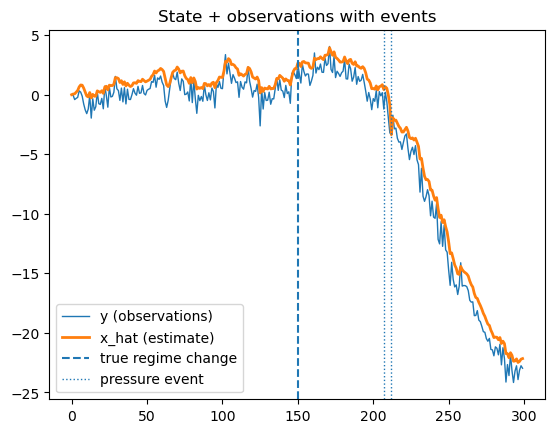

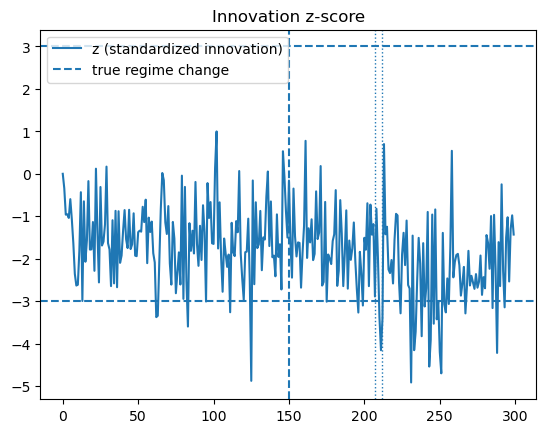

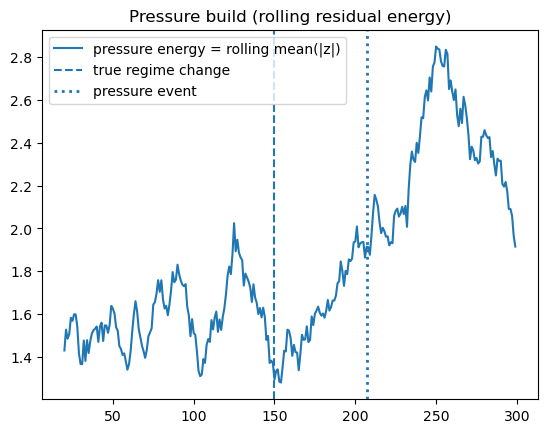

In [31]:
W = 20
energy = np.full_like(z, np.nan, dtype=float)
for t in range(W, len(z)):
    energy[t] = float(np.mean(np.abs(z[t-W+1:t+1])))

t = np.arange(len(y))

plt.figure()
plt.plot(t, y, label="y (observations)", linewidth=1)
plt.plot(t, x_hat, label="x_hat (estimate)", linewidth=2)
plt.axvline(true_change_t, linestyle="--", label="true regime change")
for et, kind, _ in events:
    plt.axvline(et, linestyle=":", linewidth=1, label=f"{kind} event" if et == events[0][0] else None)
plt.legend()
plt.title("State + observations with events")
plt.show()

plt.figure()
plt.plot(t, z, label="z (standardized innovation)")
plt.axhline(3.0, linestyle="--")
plt.axhline(-3.0, linestyle="--")
plt.axvline(true_change_t, linestyle="--", label="true regime change")
for et, kind, _ in events:
    plt.axvline(et, linestyle=":", linewidth=1)
plt.legend()
plt.title("Innovation z-score")
plt.show()

plt.figure()
plt.plot(t, energy, label="pressure energy = rolling mean(|z|)")
plt.axvline(true_change_t, linestyle="--", label="true regime change")
for et, kind, info in events:
    if kind == "pressure":
        plt.axvline(et, linestyle=":", linewidth=2, label="pressure event")
plt.legend()
plt.title("Pressure build (rolling residual energy)")
plt.show()


In [11]:
print('max |z|:', np.max(np.abs(z)))
print('count |z|>3:', np.sum(np.abs(z) > 3.0))
print('count |z| > 2:', np.sum(np.abs(z) > 2))

pre = z[:150]
post = z[150:]
print('pre max |z|', np.max(np.abs(pre)))
print('post max', np.max(np.abs(post)))
print('pre mean |z|', np.mean(np.abs(pre)))
print('post mean |z|', np.mean(np.abs(post)))

max |z|: 4.917303882860164
count |z|>3: 31
count |z| > 2: 114
pre max |z| 4.878589128147262
post max 4.917303882860164
pre mean |z| 1.5388462354619212
post mean |z| 2.088867885442499


In [12]:
print('len(y):', len(y))
print('nonzero z count:', np.count_nonzero(z))
print('last 10 z:', z[-10:])
print('last 10 innovations:', innov[-10:])
print('P min/max:', float(np.min(innov)), float(np.max(innov)))

nz = np.where(z != 0)[0]
print('last non zero z index:', int(nz[-1]) if len(nz) else None)

len(y): 300
nonzero z count: 299
last 10 z: [-2.6466628  -0.24890258 -2.28915687 -3.14656033 -1.50543968 -1.02419311
 -2.5370683  -1.30149574 -0.97892879 -1.43182542]
last 10 innovations: [-2.33616352 -0.21970201 -2.02059922 -2.77741443 -1.32882559 -0.90403756
 -2.23942635 -1.1488078  -0.86408353 -1.26384756]
P min/max: -4.340419286393077 1.129693459227344
last non zero z index: 299


*The detector should be firing under the circumstances of having |z| > 3. But I have required 3 in a row. Are thise 31 instances mostly isolated/spiky, or do hey come in runs of 3+ sustained incompatibility?*

In [13]:
thr = 3.0
mask = (np.abs(z) > thr).astype(int)

#lengths of consecutive runs where mask==1
runs = []
run = 0
for m in mask:
    if m == 1:
        run += 1
    else:
        if run > 0:
            runs.append(run)

        run = 0
if run > 0:
    runs.append(run)

print('Number of |z|>3 runs:', len(runs))
print('Run lengths, sorted:', sorted(runs, reverse=True)[:10])
print('max run length', max(runs) if runs else 0)

Number of |z|>3 runs: 24
Run lengths, sorted: [3, 2, 2, 2, 2, 2, 1, 1, 1, 1]
max run length 3


In [14]:
# did z shift around 150? 

def summarize_window(z, start, end):
    w = z[start:end]
    return{
        'mean': float(np.mean(w)),
        'mean_abs': float(np.mean(np.abs(w))),
        'max_abs': float(np.max(np.abs(w))),
        'pct_|z|>2': float(np.mean(np.abs(w) > 2.0)),
        'pct_|z|>3': float(np.mean(np.abs(w) > 3.0)),
    }

print('z window [120:150]:', summarize_window(z, 120, 150))        
print('z window [150:180]:', summarize_window(z, 150, 180))
print('z window [180:212]:', summarize_window(z, 180, 212))
print('z window [212:240]:', summarize_window(z, 212, 240))

# If there is a jump in mean or mean_abs, i'll use a cumulative 
# change pooint style detector

z window [120:150]: {'mean': -1.5507646429415163, 'mean_abs': 1.5897767054845495, 'max_abs': 4.878589128147262, 'pct_|z|>2': 0.23333333333333334, 'pct_|z|>3': 0.03333333333333333}
z window [150:180]: {'mean': -1.5252380012432445, 'mean_abs': 1.5891526815448325, 'max_abs': 3.013524277155416, 'pct_|z|>2': 0.23333333333333334, 'pct_|z|>3': 0.03333333333333333}
z window [180:212]: {'mean': -1.9354208000773643, 'mean_abs': 1.9354208000773643, 'max_abs': 4.157163752226939, 'pct_|z|>2': 0.4375, 'pct_|z|>3': 0.125}
z window [212:240]: {'mean': -2.2014250081052684, 'mean_abs': 2.2514683039561354, 'max_abs': 4.917303882860164, 'pct_|z|>2': 0.5714285714285714, 'pct_|z|>3': 0.21428571428571427}


*The true regime change at t=150 is structural in the simulator, but in my observed evidence(standardized innovtion), the mismatch doesn't become statistically loud until ~180-212).*

*A regime change 'in truth' before it becomes detectabvle 'in evidence' is a property of the signal-to-noise and my decsion rule.*

# Late Bloomer?

The model shows a persistent negative innovation bias, and the structural shift expresses itself as rising residual energy before the shock detector finally triggers on a tail cluster.

## Results
- Tue regime change: t = 150
- Pressure event detected: t = 207(lag = 57)
- Shcoj event detected: t = 212 (lag = 62)

# Interpretation
- Structural change precedes detectable evidence.
- Sustained residual energy signals degredation before failure.
- Shock confirms irreversible failure.

# Key Modeling Insights
- Events are decision points.
- Detectioin lag is a property of dignal-to-noise.
- Pressure is a latent condition inferred from time-in-state.
- SHock and pressure represent different operational thresholds.
